In [2]:
import yfinance as yf

tickers = ["RELIANCE.NS","HDFCBANK.NS","ICICIBANK.NS","INFY.NS","TCS.NS","LT.NS"]

data = yf.download(
    tickers,
    start="2019-01-01",
    end="2025-01-01",
    auto_adjust=False
)["Adj Close"]

data.to_csv("portfolio_prices.csv")
data.head()


[*********************100%***********************]  6 of 6 completed


Ticker,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,LT.NS,RELIANCE.NS,TCS.NS
Date,,,,,,
2019-01-01,504.392517,350.957001,553.448364,1295.537842,498.490570,1610.928223
2019-01-02,499.790253,351.777161,556.777222,1280.802612,491.998230,1628.283569
2019-01-03,495.868958,350.474609,556.860474,1253.398560,485.928284,1608.515381
2019-01-04,497.195587,352.356018,550.119690,1247.153931,488.551910,1588.958618
2019-01-07,497.946960,354.768127,558.982422,1243.335449,491.264526,1606.779907


In [4]:
import pandas as pd

data = pd.read_csv("portfolio_prices.csv", index_col=0, parse_dates=True)
returns = data.pct_change().dropna()

In [5]:
import numpy as np

mean_returns = returns.mean()
cov_matrix = returns.cov()

In [6]:
import scipy.optimize as sco

def portfolio_performance(weights, mean_returns, cov_matrix):
    ret = np.sum(mean_returns * weights) * 252
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix*252, weights)))
    return ret, vol, ret/vol

def neg_sharpe(weights, mean_returns, cov_matrix):
    return -portfolio_performance(weights, mean_returns, cov_matrix)[2]

num_assets = len(data.columns)
bounds = [(0,1)] * num_assets
constraints = {'type':'eq','fun': lambda w: np.sum(w) - 1}
init_guess = np.repeat(1/num_assets, num_assets)

opt = sco.minimize(neg_sharpe, init_guess,
                   args=(mean_returns,cov_matrix),
                   method='SLSQP', bounds=bounds,
                   constraints=constraints)

opt_weights = opt.x
opt_weights

array([0.        , 0.26967935, 0.32247719, 0.16605594, 0.10258715,
       0.13920037])

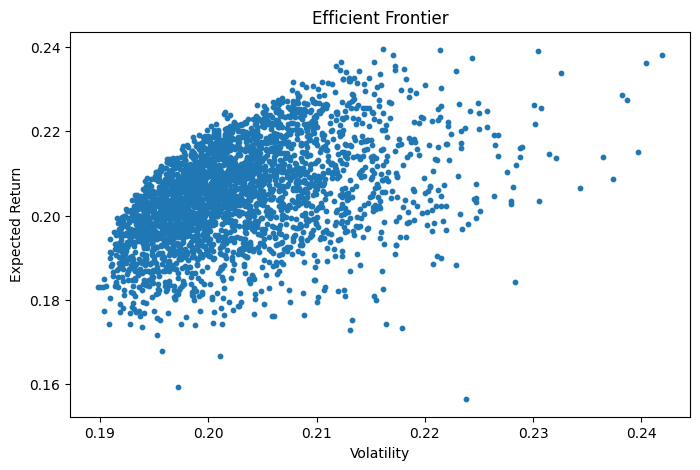

In [7]:
import matplotlib.pyplot as plt

port_returns = []
port_vol = []

for _ in range(3000):
    w = np.random.random(num_assets)
    w /= np.sum(w)
    r, v, s = portfolio_performance(w, mean_returns, cov_matrix)
    port_returns.append(r)
    port_vol.append(v)

plt.figure(figsize=(8,5))
plt.scatter(port_vol, port_returns, s=10)
plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.title("Efficient Frontier")
plt.show()

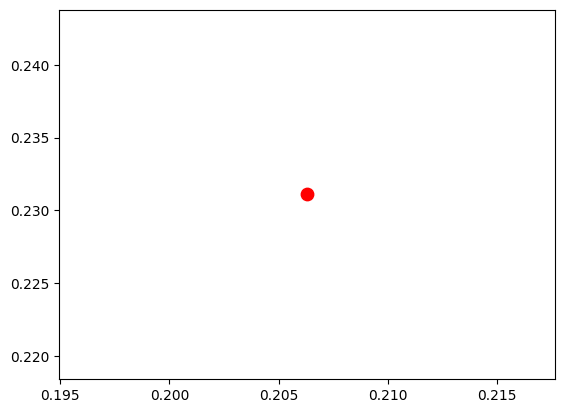

In [8]:
ret, vol, sharpe = portfolio_performance(opt_weights, mean_returns, cov_matrix)
plt.scatter(vol, ret, color="red", s=80)

In [9]:
for t, w in zip(data.columns, opt_weights):
    print(t, ":", round(w,4))

print("Return:", ret)
print("Volatility:", vol)
print("Sharpe:", sharpe)

HDFCBANK.NS : 0.0
ICICIBANK.NS : 0.2697
INFY.NS : 0.3225
LT.NS : 0.1661
RELIANCE.NS : 0.1026
TCS.NS : 0.1392
Return: 0.23108745679212178
Volatility: 0.20629544848271664
Sharpe: 1.1201771948520822


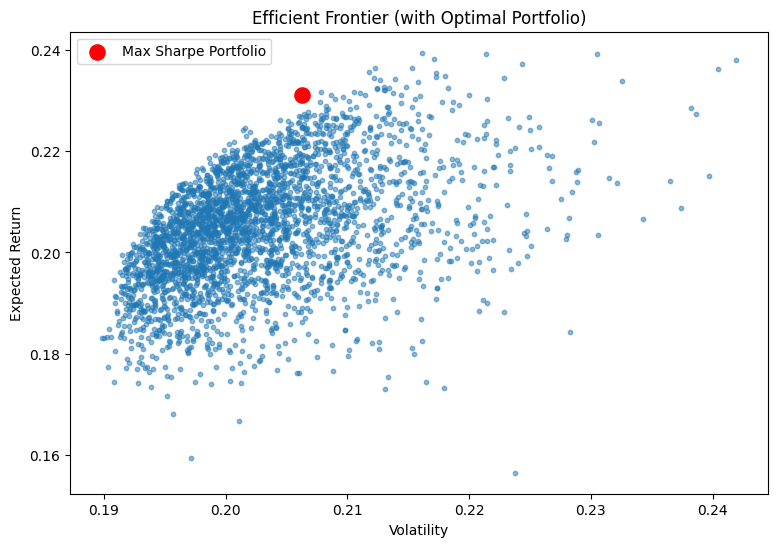

In [10]:
plt.figure(figsize=(9,6))
plt.scatter(port_vol, port_returns, s=10, alpha=0.5)
plt.scatter(vol, ret, color='red', s=120, label='Max Sharpe Portfolio')
plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.title("Efficient Frontier (with Optimal Portfolio)")
plt.legend()
plt.show()

In [11]:
import pandas as pd

weights_df = pd.DataFrame({
    'Ticker': data.columns,
    'Weight': opt_weights
})

weights_df.sort_values(by="Weight", ascending=False)

,Ticker,Weight
2,INFY.NS,0.322477
1,ICICIBANK.NS,0.269679
3,LT.NS,0.166056
5,TCS.NS,0.139200
4,RELIANCE.NS,0.102587
0,HDFCBANK.NS,0.000000
